# 📊 Explorando activos financieros con Python y pandas
## Análisis exploratorio de activos de un portafolio

En este laboratorio aprenderás a obtener datos financieros, explorarlos con **pandas**, transformarlos y encontrar información útil para analizar activos.

> **Idea clave:** primero observamos los datos, después calculamos y finalmente interpretamos.


## 🧭 Ruta de aprendizaje

**1. Conectar con los datos** → Yahoo Finance y tickers  
**2. Conocer la información** → DataFrame y estructura  
**3. Mirar antes de calcular** → exploración inicial  
**4. Seguir el comportamiento** → precios y gráficos  
**5. Medir los cambios** → rendimientos  
**6. Describir lo encontrado** → estadísticas  
**7. Comparar para comprender** → varios activos  
**8. Buscar relaciones** → correlación  
**9. Tu análisis** → misión individual


# 1. 🔌 Conectar con los datos

### ¿De dónde obtenemos la información?

Yahoo Finance contiene información histórica de diferentes activos financieros. Para acceder a ella desde Python utilizaremos **yfinance**.

Un **ticker** es el código utilizado para identificar un activo. Por ejemplo: `AAPL`, `MSFT`, `AMZN` o `GOOGL`.


In [1]:
!pip -q install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Nuestro primer activo

Comencemos con Apple. Más adelante cambiaremos el ticker para trabajar con los activos asignados.

In [3]:
ticker = "AAPL"

datos = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

datos.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271568,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568901,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139183,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799942,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954918,75.797501,76.110001,74.290001,74.290001,132079200


# 2. 🧩 Conocer la información

Lo que acabamos de obtener es un **DataFrame de pandas**: una estructura de datos organizada en filas y columnas.

Antes de analizar, necesitamos saber qué contiene la tabla y cómo está organizada.


In [4]:
datos.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271568,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568901,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139183,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799942,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954918,75.797501,76.110001,74.290001,74.290001,132079200


In [5]:
datos.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-12-24,256.339722,258.200012,258.209991,255.289993,255.490005,23234700
2024-12-26,257.153809,259.019989,260.100006,257.630005,258.190002,27237100
2024-12-27,253.748535,255.589996,258.700012,253.059998,257.829987,42355300
2024-12-30,250.382950,252.199997,253.500000,250.750000,252.229996,35557500
2024-12-31,248.615799,250.419998,253.279999,249.429993,252.440002,39480700


In [6]:
datos.shape

(1258, 6)

In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  1258 non-null   float64
 1   (Close, AAPL)      1258 non-null   float64
 2   (High, AAPL)       1258 non-null   float64
 3   (Low, AAPL)        1258 non-null   float64
 4   (Open, AAPL)       1258 non-null   float64
 5   (Volume, AAPL)     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


### 🧠 Piensa

- ¿Qué representa una fila?
- ¿Qué representa una columna?
- ¿Qué información contiene el índice?
- ¿Cuántas observaciones tenemos?

Estas preguntas forman parte del **análisis exploratorio de datos**.

# 3. 🔎 Mirar antes de calcular

Una exploración inicial nos ayuda a detectar características, diferencias o posibles problemas antes de comenzar a realizar cálculos.

In [8]:
datos.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.247344,154.108800,155.660348,152.379123,153.951948,9.057103e+07
std,41.815935,41.520877,41.654310,41.305929,41.466618,5.324438e+07
min,54.117027,56.092499,57.125000,53.152500,57.020000,2.323470e+07
25%,126.170300,129.624996,130.755005,127.505001,129.017506,5.546825e+07
50%,149.839386,152.805000,154.570000,150.825005,152.575005,7.628335e+07
75%,175.750462,178.850006,180.160000,177.115005,178.500004,1.077425e+08
max,257.153809,259.019989,260.100006,257.630005,258.190002,4.265100e+08


In [9]:
datos.isna().sum()

,,0
Price,Ticker,
Adj Close,AAPL,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


### 🧠 Interpreta

No basta con ejecutar `describe()`. Observa los resultados y piensa: ¿qué nos permite conocer cada medida sobre los datos?

# 4. 📈 Seguir el comportamiento

Comencemos observando el precio de cierre. Una gráfica puede ayudarnos a identificar tendencias y cambios que serían difíciles de observar en una tabla.

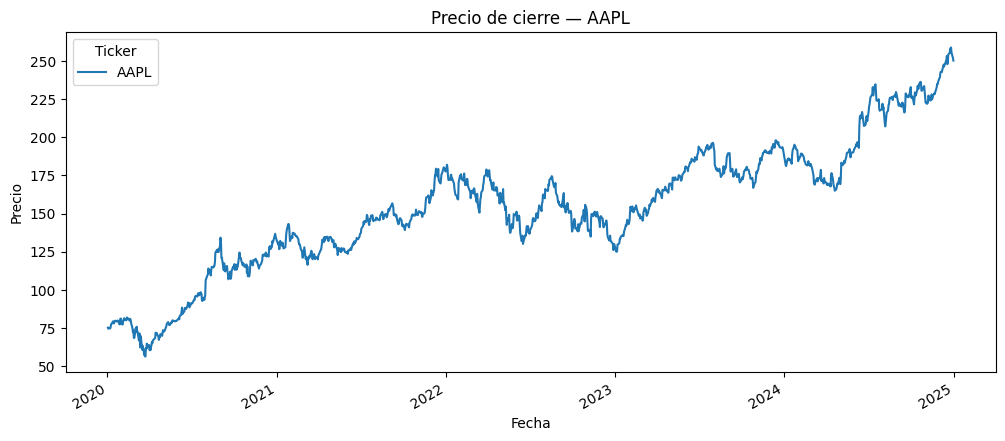

In [10]:
cierre = datos["Close"]

cierre.plot(figsize=(12, 5))
plt.title(f"Precio de cierre — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

### 👀 Observa

Describe brevemente lo que encuentras:

- ¿Se observan períodos de crecimiento o disminución?
- ¿Hay cambios especialmente fuertes?
- ¿El comportamiento parece estable durante todo el período?


# 5. 🔄 Medir los cambios

Comparar solamente precios puede ser insuficiente porque los activos pueden comenzar con valores muy diferentes.

Una alternativa es estudiar los **rendimientos**, que expresan el cambio de una observación respecto a la anterior.


### Cálculo de Rendimientos Financieros

Existen dos formas principales de calcular los rendimientos financieros: discretos y logarítmicos.

#### 1. Rendimientos Discretos (o Simples)

Los rendimientos discretos representan el cambio porcentual en el precio de un activo entre dos períodos consecutivos. Son intuitivos y fáciles de interpretar, ya que reflejan directamente la ganancia o pérdida en relación con el precio inicial. Son adecuados para el cálculo de rendimientos de un solo período.

La fórmula para el rendimiento discreto $R_t$ en el período $t$ es:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_{t-1}$ es el precio del activo en el tiempo $t-1$.

### Ejemplo de Cálculo de Rendimientos

Consideremos los siguientes precios:
*   Precio Anterior ($P_{t-1}$): **100**
*   Precio Actual ($P_t$): **110**

#### 1. Cálculo del Rendimiento Discreto

Utilizando la fórmula:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{110 - 100}{100} = \frac{10}{100} = 0.10$$

El rendimiento discreto es **0.10** o **10%**.


In [11]:
rendimiento = cierre.pct_change()
rendimiento.head()

Ticker,AAPL
Date,
2020-01-02,NaN
2020-01-03,-0.009722
2020-01-06,0.007968
2020-01-07,-0.004703
2020-01-08,0.016086


El primer valor aparece como `NaN` porque no existe una observación anterior con la cual compararlo.


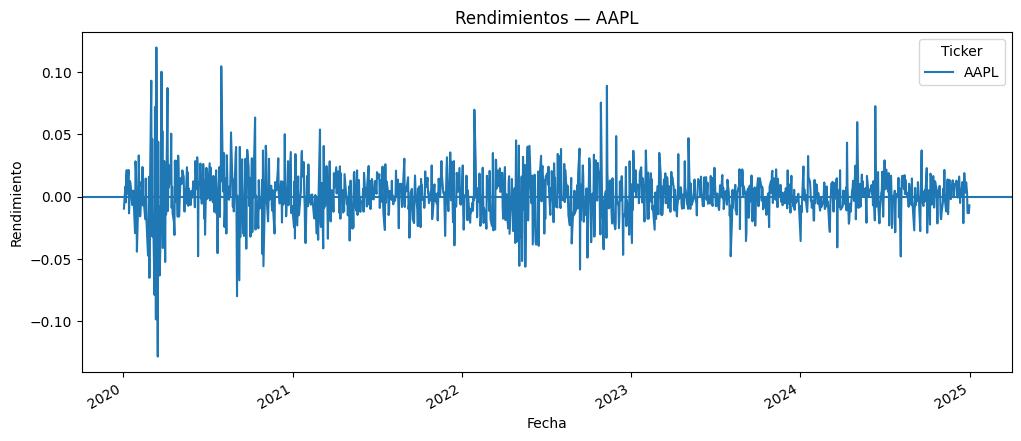

In [12]:
rendimiento.plot(figsize=(12, 5))

plt.axhline(0)
plt.title(f"Rendimientos — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.show()

# 6. 📐 Describir lo encontrado

Ahora podemos utilizar las estadísticas descriptivas para conocer mejor la distribución de los rendimientos.

In [13]:
rendimiento.describe()

Ticker,AAPL
count,1257.000000
mean,0.001157
std,0.019957
min,-0.128647
25%,-0.008425
50%,0.001172
75%,0.011989
max,0.119808


### Interpretación de las Estadísticas Descriptivas de Rendimientos

Al analizar la tabla de estadísticas descriptivas para los rendimientos, observamos lo siguiente:

*   **Promedio (Mean):** El promedio de los rendimientos es cercano a cero (aproximadamente 0.1157%). Esto sugiere que, a lo largo del periodo analizado, el rendimiento diario promedio del activo ha sido muy bajo, lo cual es común en series de rendimientos diarios que no muestran una tendencia marcada a largo plazo.

*   **Desviación Estándar (Std):** La desviación estándar es de aproximadamente 1.99%. Esta medida nos indica la dispersión o volatilidad de los rendimientos diarios. Un valor del 2% diario significa que, en promedio, los rendimientos suelen desviarse en un 2% (ya sea al alza o a la baja) de la media. En el contexto financiero, una mayor desviación estándar implica una mayor volatilidad y, por ende, un mayor riesgo.

*   **Mínimo (Min):** El rendimiento mínimo observado es de aproximadamente -12.86%. Esto representa la mayor pérdida porcentual experimentada por el activo en un solo día durante el periodo. Si se hubieran invertido 100 pesos, una pérdida del 12.86% implicaría que el valor de la inversión se reduciría a 87.14 pesos en ese día.

*   **Máximo (Max):** El rendimiento máximo observado es de aproximadamente 11.98%. Esta es la mayor ganancia porcentual en un solo día. Es notable que la máxima pérdida (-12.86%) es ligeramente superior a la máxima ganancia (11.98%), lo que podría indicar una asimetría en los movimientos extremos del activo, con pérdidas más severas en ciertos días.

*   **Percentil 25% (Q1):** El primer cuartil es de -0.84%. Esto significa que el 25% de los días, el rendimiento del activo fue igual o inferior a -0.84%, lo que implica una pérdida para el 25% de las observaciones.

*   **Percentil 50% (Mediana):** La mediana (percentil 50%) es de aproximadamente 0.1172%. Esto indica que el 50% de los rendimientos fueron iguales o inferiores a este valor, y el otro 50% fueron iguales o superiores. Al ser cercano a cero y ligeramente positivo, refuerza la idea de que los rendimientos oscilan alrededor de cero.

*   **Percentil 75% (Q3):** El tercer cuartil es de 1.19%. Esto significa que el 75% de los días, el rendimiento del activo fue igual o inferior a 1.19%, o dicho de otra forma, el 25% de los días la rentabilidad fue superior a 1.19%.

**Ausencia de tendencia y oscilación alrededor de cero:** Esto es típico en las series de rendimientos de activos. A diferencia de los precios, que suelen mostrar tendencias alcistas o bajistas a largo plazo, los rendimientos diarios (o periódicos) tienden a fluctuar en torno a su promedio (que a menudo es cercano a cero). Esto indica que, en el corto plazo, los movimientos positivos y negativos se compensan, sin una dirección clara y sostenida.

**Dispersión alrededor de cero y su variabilidad (Volatilidad)**: Has identificado correctamente que la dispersión de los rendimientos alrededor de cero no es constante. Esta dispersión se mide con la desviación estándar, y en el ámbito financiero se conoce como volatilidad. Una mayor dispersión (picos más altos o valles más profundos) significa mayor volatilidad, lo que implica que el precio del activo está experimentando cambios más grandes en un corto período de tiempo. Los periodos de "alta dispersión" se correlacionan con alta volatilidad (mayor riesgo), mientras que los de "baja dispersión" indican baja volatilidad (menor riesgo).

**Rangos de máximos y mínimos (Variabilidad Extrema):** La observación de que los rendimientos máximos superan el 10% y los mínimos caen por debajo del -10% es crucial. Esto te da una idea del rango extremo de movimientos que el activo ha experimentado en un solo día. Rendimientos tan altos o tan bajos en un solo día son eventos significativos que reflejan la magnitud de los shocks o noticias que afectaron al activo en esos momentos.

# Percentiles extremos


In [14]:
print("Percentil 1:", rendimiento.quantile(0.01))
print("Percentil 5:", rendimiento.quantile(0.05))

Percentil 1: Ticker
AAPL   -0.050317
Name: 0.01, dtype: float64
Percentil 5: Ticker
AAPL   -0.030125
Name: 0.05, dtype: float64


## Interpretación de Percentiles como Pérdida Máxima Esperada (VaR)

Los percentiles 1 y 5 de los rendimientos son a menudo interpretados en el contexto de **Valor en Riesgo (VaR)**, una medida clave en finanzas para cuantificar la pérdida potencial de una inversión.

*   El **percentil 1** de aproximadamente -0.050317 (-5.03%) significa que existe un **1% de probabilidad** de que el activo experimente una pérdida de 5.03% o más de su valor en un día determinado, bajo condiciones normales de mercado. Esto se puede entender como la **máxima pérdida esperada** que el activo podría sufrir con un nivel de confianza del 99% (es decir, hay solo un 1% de posibilidades de que la pérdida real sea mayor).

*   El **percentil 5** de aproximadamente -0.030125 (-3.01%) significa que existe un **5% de probabilidad** de que el activo experimente una pérdida de 3.01% o más de su valor en un día determinado. Esto se interpreta como la **máxima pérdida esperada** con un nivel de confianza del 95% (hay un 5% de posibilidades de que la pérdida real sea mayor).

En resumen, estos valores proporcionan una estimación de las pérdidas extremas que un inversor podría enfrentar con este activo en un día, junto con la probabilidad de que ocurran.

In [15]:
print("Promedio:", rendimiento.mean())
print("Desviación estándar:", rendimiento.std())
print("Mínimo:", rendimiento.min())
print("Máximo:", rendimiento.max())

Promedio: Ticker
AAPL    0.001157
dtype: float64
Desviación estándar: Ticker
AAPL    0.019957
dtype: float64
Mínimo: Ticker
AAPL   -0.128647
dtype: float64
Máximo: Ticker
AAPL    0.119808
dtype: float64


### 🧠 Interpreta

¿Qué nos dice el promedio? ¿Qué información aporta la desviación estándar? ¿Qué representan los valores mínimo y máximo?

Recuerda: **una estadística tiene sentido cuando podemos explicar qué significa en el contexto financiero.**

# 7. ⚖️ Comparar para comprender

Ahora incorporaremos varios activos. La comparación nos permitirá observar diferencias en su comportamiento.

In [16]:
activos = ["AAPL", "MSFT", "AMZN"]

datos = yf.download(
    activos,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

precios = datos["Close"]
precios.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-02,75.087502,94.900497,160.619995
2020-01-03,74.357498,93.748497,158.619995
2020-01-06,74.949997,95.143997,159.029999
2020-01-07,74.597504,95.343002,157.580002
2020-01-08,75.797501,94.598503,160.089996


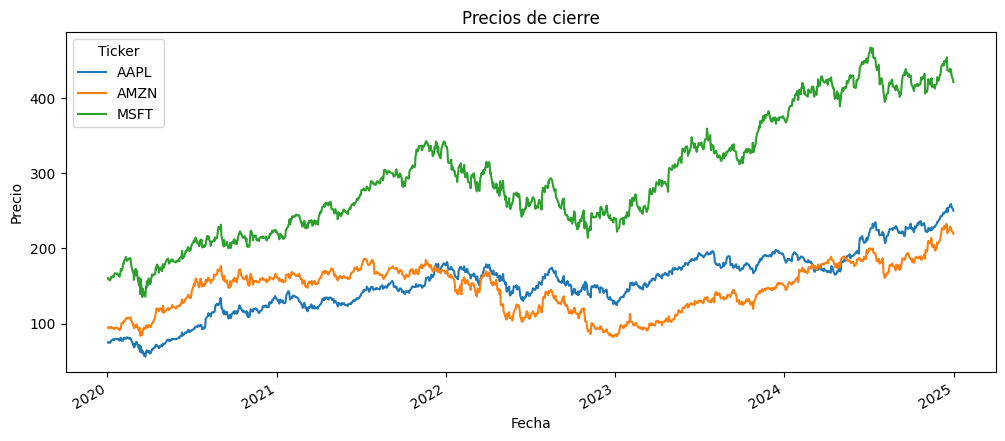

In [17]:
precios.plot(figsize=(12, 5))

plt.title("Precios de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

Los precios pueden tener escalas diferentes. Para comparar su evolución desde un mismo punto de referencia podemos construir un índice base 100.

### Normalización de Precios (Base 100)

Para comparar la evolución de diferentes activos financieros, es útil **normalizar sus precios a una base común**, como 100. Esto permite observar cómo ha crecido o disminuido el valor de cada activo desde un punto de partida equitativo, independientemente de sus precios absolutos iniciales.

La fórmula para normalizar un precio $P_t$ en el tiempo $t$ a una base 100 es:

$$\Large P_{t, \text{normalizado}} = \frac{P_t}{P_0} \times 100$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_0$ es el precio inicial (o precio en el punto de partida) del activo.

#### Ejemplo:

Supongamos que tenemos los siguientes precios para un activo en tres días:

*   Día 1 ($P_0$): **75.00**
*   Día 2 ($P_1$): **74.35**
*   Día 3 ($P_2$): **74.95**

Aplicando la fórmula de normalización:

*   **Día 1:** $\frac{75.00}{75.00} \times 100 = 100$
*   **Día 2:** $\frac{74.35}{75.00} \times 100 \approx 99.13$
*   **Día 3:** $\frac{74.95}{75.00} \times 100 \approx 99.93$

Estos valores normalizados nos permiten ver el cambio porcentual relativo de cada día respecto al día inicial (base 100).

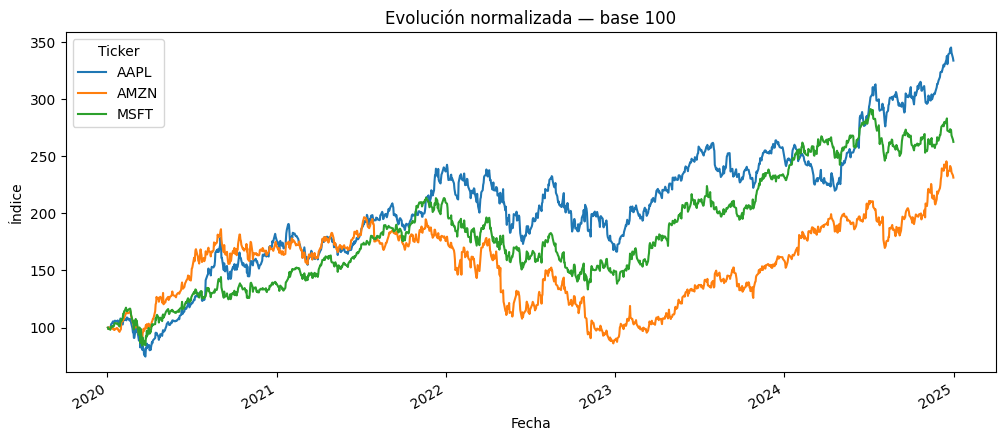

In [18]:
precios_normalizados = precios / precios.iloc[0] * 100

precios_normalizados.plot(figsize=(12, 5))
plt.title("Evolución normalizada — base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()

# 8. 🔗 Buscar relaciones

En un portafolio no solo importa cómo se comporta cada activo individualmente. También interesa saber cómo se relacionan entre sí.

Primero calculamos los rendimientos de todos los activos.

In [19]:
rendimientos = precios.pct_change()
rendimientos.head()

Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012139,-0.012452
2020-01-06,0.007968,0.014886,0.002585
2020-01-07,-0.004703,0.002092,-0.009118
2020-01-08,0.016086,-0.007809,0.015928


In [20]:
correlacion = rendimientos.corr()
correlacion

Ticker,AAPL,AMZN,MSFT
Ticker,,,
AAPL,1.000000,0.591883,0.748121
AMZN,0.591883,1.000000,0.678666
MSFT,0.748121,0.678666,1.000000


### Análisis Financiero de la Matriz de Correlación

La matriz de correlación de los rendimientos es una herramienta fundamental en finanzas para entender la relación entre los movimientos de diferentes activos y es clave para la **diversificación de carteras**.

*   **Correlación Positiva (cercana a +1):** Indica que los rendimientos de los activos tienden a moverse en la misma dirección. Si el rendimiento de un activo sube, es muy probable que el del otro también lo haga, y viceversa. En nuestra matriz, podemos observar una fuerte correlación positiva entre **AAPL y MSFT (0.748)**. Esto significa que si las acciones de Apple suben, las de Microsoft probablemente también lo harán, y si bajan, las de Microsoft también tenderán a bajar. Una correlación alta reduce los beneficios de la diversificación, ya que los activos no actúan como "amortiguadores" el uno del otro en momentos de caída.

*   **Correlación Negativa (cercana a -1):** Sugiere que los rendimientos de los activos tienden a moverse en direcciones opuestas. Si un activo sube, el otro tiende a bajar, y viceversa. Este tipo de correlación es muy deseable para la diversificación, ya que ayuda a mitigar el riesgo de la cartera. En nuestra matriz, no observamos correlaciones negativas fuertes, lo cual es común entre acciones del mismo sector o mercado.

*   **Correlación Cero (cercana a 0):** Implica que no hay una relación lineal predecible entre los movimientos de los rendimientos de los activos. Su comportamiento es independiente el uno del otro. Aunque no reduce el riesgo tan eficazmente como una correlación negativa, sigue siendo beneficioso para la diversificación en comparación con una correlación positiva alta.

#### Implicaciones para la Diversificación:

Para construir un portafolio robusto y diversificado, se busca incluir activos con **baja o negativa correlación**. Esto se debe a que, si un activo experimenta una caída, es probable que otro activo con baja o negativa correlación no caiga (o incluso suba), compensando así parte de la pérdida. Los activos en nuestra matriz muestran correlaciones positivas entre sí, lo que sugiere que son algo dependientes. Por ejemplo, **AAPL** y **AMZN** tienen una correlación de **0.592**, y **AMZN** y **MSFT** de **0.679**. Esto indica que, aunque no se mueven en perfecta sintonía, sus rendimientos sí comparten una tendencia común.

Para mejorar la diversificación, un inversor podría considerar añadir activos de diferentes sectores, geografías o tipos (por ejemplo, bonos, materias primas) que históricamente muestren una correlación más baja o negativa con los activos tecnológicos actuales.

### ¿Cómo podemos leer la correlación?

- Cerca de **1**: los movimientos tienden a ser similares.
- Cerca de **0**: la relación lineal es débil.
- Cerca de **-1**: los movimientos tienden a ser opuestos.

### 💭 Pregunta

Si dos activos presentan una correlación elevada, ¿qué podría significar esto al pensar en diversificación?

# 9. 🚀 Tu análisis

Ahora repite el proceso con los **activos que te fueron asignados**.

Tu análisis debe seguir esta secuencia:

**Obtener → Conocer → Explorar → Transformar → Describir → Comparar → Relacionar → Interpretar**

### Tu misión

1. Obtén los datos históricos desde Yahoo Finance.
2. Explora la estructura del DataFrame.
3. Revisa los datos y los valores faltantes.
4. Observa el comportamiento de los precios.
5. Calcula los rendimientos.
6. Describe los rendimientos con estadísticas.
7. Compara visualmente los activos.
8. Explora la correlación.
9. Escribe una conclusión sustentada en los resultados.

> **Pregunta final:** ¿Qué diferencias encontraste entre los activos y qué información consideras importante conocer antes de incorporarlos a un portafolio?


---
## 9.1 Obtener — mis activos asignados

Estos son los tickers que me asignó la plataforma: **ADBE, MS, COP, MRK, WMT y UPS**. Uso el mismo período del ejemplo (2020-01-01 a 2025-01-01) para que los resultados sean comparables con lo visto en clase.

In [21]:
from itertools import combinations
from IPython.display import display, Markdown

# Tickers asignados a mí (los de "Copiar mis tickers")
mis_tickers = ["ADBE", "MS", "COP", "MRK", "WMT", "UPS"]
inicio, fin = "2020-01-01", "2025-01-01"

datos_mis = yf.download(mis_tickers, start=inicio, end=fin, auto_adjust=False)
datos_mis.head()

[*********************100%***********************]  6 of 6 completed


Price        Adj Close                                                         \
Ticker            ADBE        COP        MRK         MS        UPS        WMT   
Date                                                                            
2020-01-02  334.429993  51.430088  71.158615  42.371368  87.781105  36.203289   
2020-01-03  331.809998  51.618652  70.547836  41.687431  87.728508  35.883686   
2020-01-06  333.709991  52.231464  70.849350  41.540874  87.337654  35.810631   
2020-01-07  333.390015  52.231464  68.962936  41.459446  87.187347  35.478855   
2020-01-08  337.869995  51.021538  68.499031  41.988686  87.683403  35.357098   

Price            Close                                   ...       Open  \
Ticker            ADBE        COP        MRK         MS  ...        MRK   
Date                                                     ...              
2020-01-02  334.429993  65.459999  87.824425  52.040001  ...  86.908394   
2020-01-03  331.809998  65.699997  87.070610  51.200001  ...  86.526718   
2020-01-06  333.709991  66.480003  87.442749  51.020000  ...  87.051529   
2020-01-07  333.390015  66.480003  85.114502  50.919998  ...  86.641220   
2020-01-08  337.869995  64.940002  84.541985  51.570000  ...  85.009544   

Price                                          Volume                     \
Ticker             MS         UPS        WMT     ADBE      COP       MRK   
Date                                                                       
2020-01-02  51.200001  117.680000  39.619999  1990100  4122800   8251428   
2020-01-03  51.220001  114.970001  39.423332  1577600  6333200   5903698   
2020-01-06  50.669998  115.449997  39.133331  1874700  8823800   7522963   
2020-01-07  51.040001  115.860001  39.086666  2500800  5974800  11132275   
2020-01-08  50.959999  115.379997  38.766666  2248500  6470100  15200506   

Price                                   
Ticker           MS      UPS       WMT  
Date                                    
2020-01-02  7808000  4158100  20294700  
2020-01-03  6706000  2477800  16197600  
2020-01-06  7476700  3381600  19336500  
2020-01-07  4538100  1952300  20540700  
2020-01-08  6185200  2016000  17627400  

[5 rows x 36 columns]

## 9.2 Conocer — estructura del DataFrame

In [22]:
display(datos_mis.head())
display(datos_mis.tail())
print("Forma (filas, columnas):", datos_mis.shape)
datos_mis.info()

Price        Adj Close                                                         \
Ticker            ADBE        COP        MRK         MS        UPS        WMT   
Date                                                                            
2020-01-02  334.429993  51.430088  71.158615  42.371368  87.781105  36.203289   
2020-01-03  331.809998  51.618652  70.547836  41.687431  87.728508  35.883686   
2020-01-06  333.709991  52.231464  70.849350  41.540874  87.337654  35.810631   
2020-01-07  333.390015  52.231464  68.962936  41.459446  87.187347  35.478855   
2020-01-08  337.869995  51.021538  68.499031  41.988686  87.683403  35.357098   

Price            Close                                   ...       Open  \
Ticker            ADBE        COP        MRK         MS  ...        MRK   
Date                                                     ...              
2020-01-02  334.429993  65.459999  87.824425  52.040001  ...  86.908394   
2020-01-03  331.809998  65.699997  87.070610  51.200001  ...  86.526718   
2020-01-06  333.709991  66.480003  87.442749  51.020000  ...  87.051529   
2020-01-07  333.390015  66.480003  85.114502  50.919998  ...  86.641220   
2020-01-08  337.869995  64.940002  84.541985  51.570000  ...  85.009544   

Price                                          Volume                     \
Ticker             MS         UPS        WMT     ADBE      COP       MRK   
Date                                                                       
2020-01-02  51.200001  117.680000  39.619999  1990100  4122800   8251428   
2020-01-03  51.220001  114.970001  39.423332  1577600  6333200   5903698   
2020-01-06  50.669998  115.449997  39.133331  1874700  8823800   7522963   
2020-01-07  51.040001  115.860001  39.086666  2500800  5974800  11132275   
2020-01-08  50.959999  115.379997  38.766666  2248500  6470100  15200506   

Price                                   
Ticker           MS      UPS       WMT  
Date                                    
2020-01-02  7808000  4158100  20294700  
2020-01-03  6706000  2477800  16197600  
2020-01-06  7476700  3381600  19336500  
2020-01-07  4538100  1952300  20540700  
2020-01-08  6185200  2016000  17627400  

[5 rows x 36 columns]

Price        Adj Close                                                \
Ticker            ADBE        COP        MRK          MS         UPS   
Date                                                                   
2024-12-24  447.940002  91.838547  93.908401  121.595062  112.785233   
2024-12-26  450.160004  91.630478  94.305000  122.523346  112.874550   
2024-12-27  446.480011  91.658859  94.144478  121.307968  112.651245   
2024-12-30  445.799988  91.819633  92.888580  120.341408  111.945541   
2024-12-31  444.679993  93.786720  93.936729  120.312683  112.642296   

Price                       Close                                    ...  \
Ticker            WMT        ADBE        COP        MRK          MS  ...   
Date                                                                 ...   
2024-12-24  91.220367  447.940002  97.110001  99.449997  127.059998  ...   
2024-12-26  91.328644  450.160004  96.889999  99.870003  128.029999  ...   
2024-12-27  90.216431  446.480011  96.919998  99.699997  126.760002  ...   
2024-12-30  89.143608  445.799988  97.089996  98.370003  125.750000  ...   
2024-12-31  88.927078  444.679993  99.169998  99.480003  125.720001  ...   

Price            Open                                      Volume           \
Ticker            MRK          MS         UPS        WMT     ADBE      COP   
Date                                                                         
2024-12-24  99.220001  125.070000  125.209999  90.370003  1685000  2677400   
2024-12-26  99.089996  126.529999  125.580002  92.540001  2131200  4325600   
2024-12-27  99.500000  127.050003  125.849998  92.129997  2947200  5889700   
2024-12-30  99.570000  124.550003  125.150002  90.730003  3473200  5238800   
2024-12-31  98.500000  126.330002  125.379997  90.570000  2285100  5556400   

Price                                            
Ticker          MRK       MS      UPS       WMT  
Date                                             
2024-12-24  3713500  2902800  1579200   8992400  
2024-12-26  4760300  3013500  3011100  10994000  
2024-12-27  6173600  3088100  2904000  11384400  
2024-12-30  6848700  2637900  2953900   9790200  
2024-12-31  6598200  2970000  3400800  11267700  

[5 rows x 36 columns]

Forma (filas, columnas): (1258, 36)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, ADBE)  1258 non-null   float64
 1   (Adj Close, COP)   1258 non-null   float64
 2   (Adj Close, MRK)   1258 non-null   float64
 3   (Adj Close, MS)    1258 non-null   float64
 4   (Adj Close, UPS)   1258 non-null   float64
 5   (Adj Close, WMT)   1258 non-null   float64
 6   (Close, ADBE)      1258 non-null   float64
 7   (Close, COP)       1258 non-null   float64
 8   (Close, MRK)       1258 non-null   float64
 9   (Close, MS)        1258 non-null   float64
 10  (Close, UPS)       1258 non-null   float64
 11  (Close, WMT)       1258 non-null   float64
 12  (High, ADBE)       1258 non-null   float64
 13  (High, COP)        1258 non-null   float64
 14  (High, MRK)        1258 non-null   float64
 15  (High, MS)        

**¿Qué representa cada parte?** Cada **fila** es un día de negociación y el **índice** guarda la fecha. Cada **columna** es una combinación de tipo de dato (Open, High, Low, Close, Adj Close, Volume) y ticker, por eso hay seis columnas por cada tipo de dato. El número de **observaciones** es el número de filas de `shape`.

## 9.3 Explorar — revisar antes de calcular

In [23]:
# Precio de cierre de cada activo, en el mismo orden en que me los asignaron
precios_mis = datos_mis["Close"][mis_tickers]

display(precios_mis.describe().round(2))

print("\nValores faltantes en el precio de cierre, por ticker:")
print(precios_mis.isna().sum())
print("\nValores faltantes en toda la tabla:", int(datos_mis.isna().sum().sum()))

Ticker,ADBE,MS,COP,MRK,WMT,UPS
count,1258.00,1258.00,1258.00,1258.00,1258.00,1258.00
mean,472.66,82.97,85.66,93.89,51.56,164.04
std,95.56,20.37,31.36,18.30,11.42,32.24
min,275.20,27.81,22.67,63.36,34.68,86.17
25%,387.99,76.03,55.54,77.02,45.46,142.87
50%,479.48,86.12,99.18,88.44,48.22,167.32
75%,535.72,96.22,112.26,109.00,53.05,186.79
max,688.37,134.99,134.94,132.96,95.70,232.11



Valores faltantes en el precio de cierre, por ticker:
Ticker
ADBE    0
MS      0
COP     0
MRK     0
WMT     0
UPS     0
dtype: int64

Valores faltantes en toda la tabla: 0


**Cómo leerlo:** `count` indica cuántos días tiene cada activo; si es igual en los seis y los faltantes son 0, la tabla está completa y alineada por fecha. `mean`, `min` y `max` muestran que los precios están en escalas distintas, así que no conviene compararlos directamente: por eso más adelante se usan rendimientos y el índice base 100.

## 9.4 Seguir el comportamiento — precios de cierre

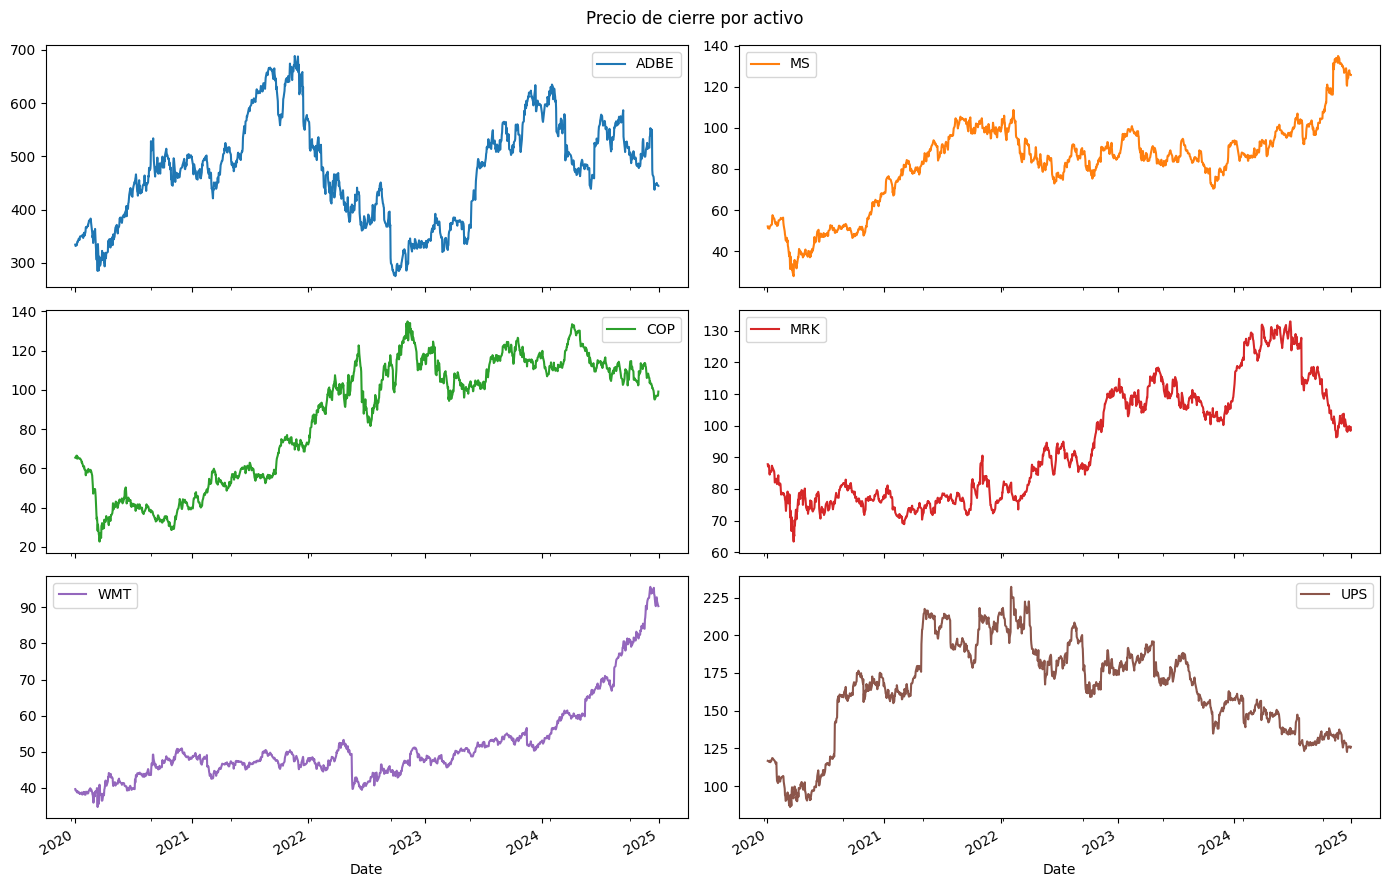

,precio_inicial,precio_final,variacion_%,precio_maximo,fecha_maximo,precio_minimo,fecha_minimo
Ticker,,,,,,,
ADBE,334.43,444.68,32.97,688.37,2021-11-19,275.20,2022-09-30
MS,52.04,125.72,141.58,134.99,2024-11-21,27.81,2020-03-23
COP,65.46,99.17,51.50,134.94,2022-11-07,22.67,2020-03-18
MRK,87.82,99.48,13.27,132.96,2024-06-24,63.36,2020-03-23
WMT,39.65,90.35,127.89,95.70,2024-12-06,34.68,2020-03-12
UPS,116.79,126.10,7.97,232.11,2022-02-02,86.17,2020-03-12


In [24]:
precios_mis.plot(subplots=True, layout=(3, 2), figsize=(14, 9), sharex=True,
                 title="Precio de cierre por activo")
plt.tight_layout()
plt.show()

resumen_precios = pd.DataFrame({
    "precio_inicial": precios_mis.iloc[0],
    "precio_final": precios_mis.iloc[-1],
    "variacion_%": (precios_mis.iloc[-1] / precios_mis.iloc[0] - 1) * 100,
    "precio_maximo": precios_mis.max(),
    "fecha_maximo": precios_mis.idxmax().dt.strftime("%Y-%m-%d"),
    "precio_minimo": precios_mis.min(),
    "fecha_minimo": precios_mis.idxmin().dt.strftime("%Y-%m-%d"),
})
display(resumen_precios.round(2))

## 9.5 Transformar — rendimientos diarios

Ticker,ADBE,MS,COP,MRK,WMT,UPS
Date,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.007834,-0.016141,0.003666,-0.008583,-0.008828,-0.000599
2020-01-06,0.005726,-0.003516,0.011872,0.004274,-0.002036,-0.004455
2020-01-07,-0.000959,-0.001960,0.000000,-0.026626,-0.009265,-0.001721
2020-01-08,0.013438,0.012765,-0.023165,-0.006726,-0.003432,0.005690


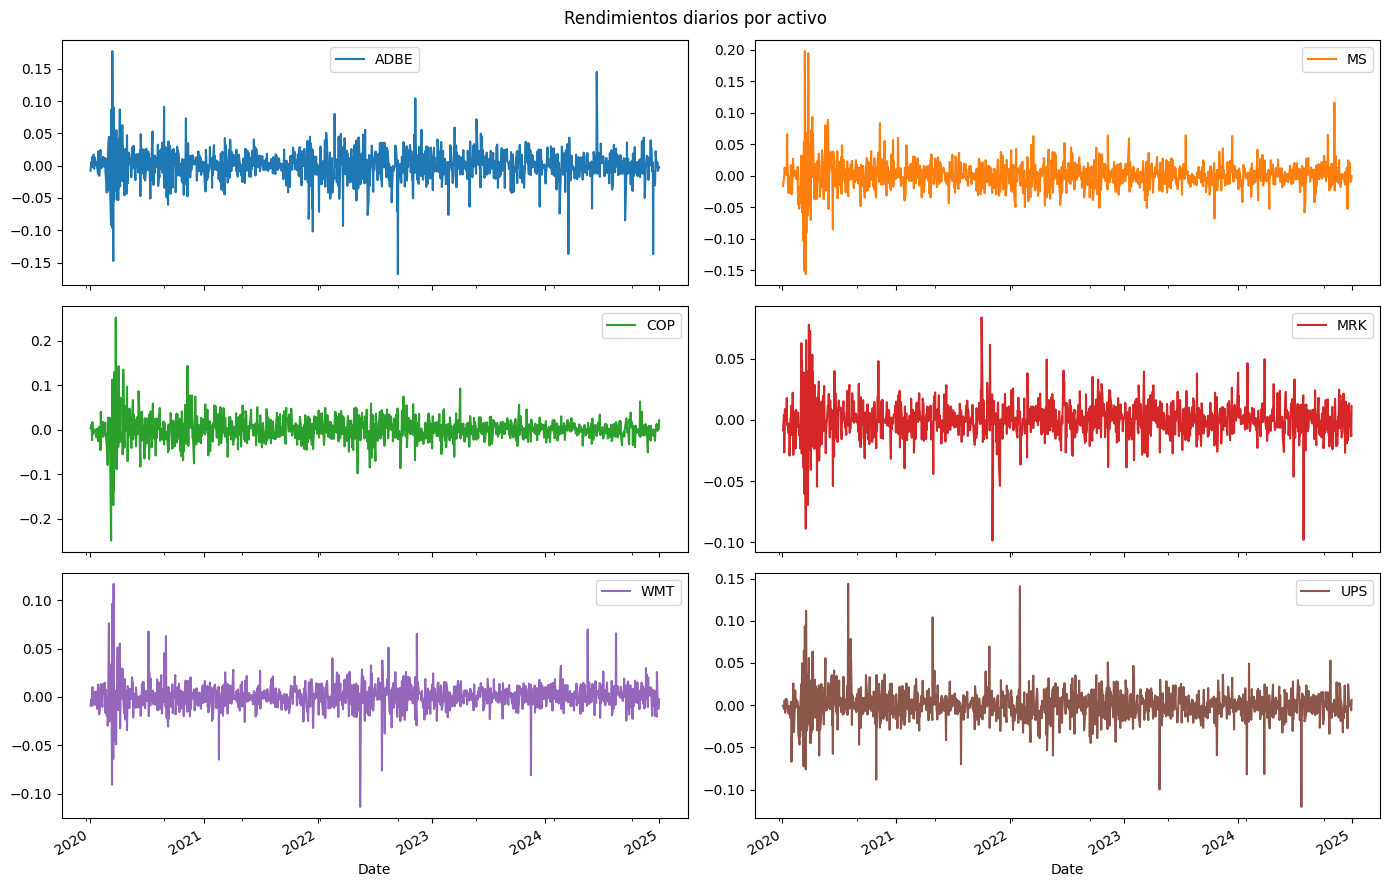

In [25]:
rend_mis = precios_mis.pct_change()
display(rend_mis.head())

rend_mis.plot(subplots=True, layout=(3, 2), figsize=(14, 9), sharex=True,
              title="Rendimientos diarios por activo")
plt.tight_layout()
plt.show()

La primera fila es `NaN` porque no hay un día anterior con el cual comparar.

## 9.6 Describir — estadísticas de los rendimientos

In [26]:
display(rend_mis.describe())

# Resumen comparativo en % (una fila por activo)
resumen_rend = pd.DataFrame({
    "promedio_%": rend_mis.mean() * 100,
    "desv_std_%": rend_mis.std() * 100,
    "minimo_%": rend_mis.min() * 100,
    "maximo_%": rend_mis.max() * 100,
    "percentil_1_%": rend_mis.quantile(0.01) * 100,
    "percentil_5_%": rend_mis.quantile(0.05) * 100,
    "volatilidad_anual_%": rend_mis.std() * (252 ** 0.5) * 100,   # extra: desv. diaria x raíz de 252 días de negociación
})
display(resumen_rend.round(3).sort_values("desv_std_%", ascending=False))

Ticker,ADBE,MS,COP,MRK,WMT,UPS
count,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000
mean,0.000529,0.000953,0.000718,0.000209,0.000757,0.000242
std,0.024490,0.022472,0.027790,0.014822,0.014236,0.019044
min,-0.167932,-0.156000,-0.248401,-0.098630,-0.113757,-0.120540
25%,-0.010748,-0.009351,-0.012433,-0.007081,-0.005869,-0.008739
50%,0.000848,0.000769,-0.000146,0.000114,0.000663,0.000000
75%,0.013438,0.011533,0.013130,0.007725,0.007320,0.009205
max,0.177193,0.197700,0.252139,0.083744,0.117085,0.143758


,promedio_%,desv_std_%,minimo_%,maximo_%,percentil_1_%,percentil_5_%,volatilidad_anual_%
Ticker,,,,,,,
COP,0.072,2.779,-24.840,25.214,-6.996,-3.726,44.116
ADBE,0.053,2.449,-16.793,17.719,-7.262,-3.617,38.877
MS,0.095,2.247,-15.600,19.770,-5.246,-3.156,35.674
UPS,0.024,1.904,-12.054,14.376,-5.540,-2.799,30.232
MRK,0.021,1.482,-9.863,8.374,-3.909,-2.108,23.529
WMT,0.076,1.424,-11.376,11.709,-3.217,-1.890,22.598


**Cómo leerlo:** el **promedio** es el rendimiento diario típico; la **desviación estándar** mide la volatilidad (qué tanto se alejan los días del promedio); **mínimo** y **máximo** son el peor y el mejor día; los **percentiles 1 y 5** indican cuánto se perdió, como mínimo, en el 1 % y el 5 % de los peores días (la lógica del VaR vista arriba). La columna de volatilidad anual es un dato adicional que usa la convención de 252 días de negociación al año.

## 9.7 Comparar — evolución en base 100

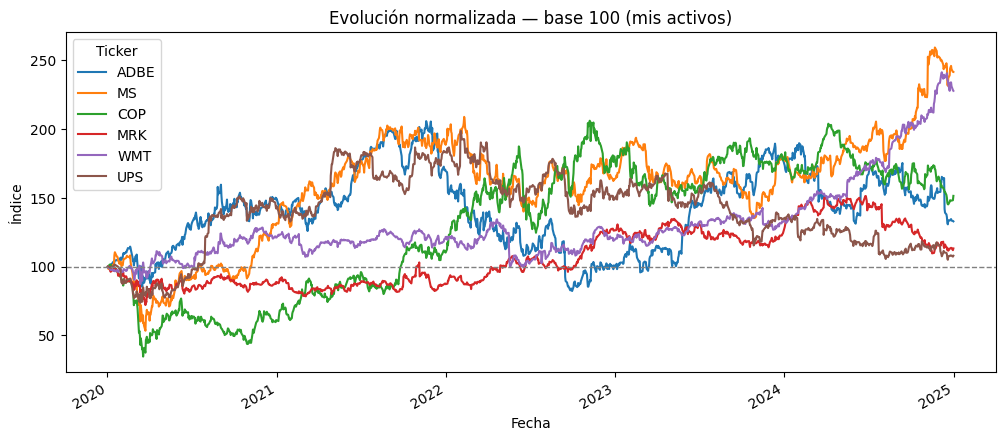

Variación acumulada del período (%), de mayor a menor:
Ticker
MS      141.6
WMT     127.9
COP      51.5
ADBE     33.0
MRK      13.3
UPS       8.0
Name: 2024-12-31 00:00:00, dtype: float64


In [27]:
precios_norm_mis = precios_mis / precios_mis.iloc[0] * 100

precios_norm_mis.plot(figsize=(12, 5))
plt.axhline(100, color="gray", linestyle="--", linewidth=1)
plt.title("Evolución normalizada — base 100 (mis activos)")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()

variacion = precios_norm_mis.iloc[-1] - 100
print("Variación acumulada del período (%), de mayor a menor:")
print(variacion.sort_values(ascending=False).round(1))

## 9.8 Relacionar — correlación de rendimientos

Ticker,ADBE,MS,COP,MRK,WMT,UPS
Ticker,,,,,,
ADBE,1.000,0.380,0.206,0.192,0.303,0.389
MS,0.380,1.000,0.567,0.317,0.265,0.450
COP,0.206,0.567,1.000,0.268,0.145,0.267
MRK,0.192,0.317,0.268,1.000,0.286,0.235
WMT,0.303,0.265,0.145,0.286,1.000,0.324
UPS,0.389,0.450,0.267,0.235,0.324,1.000


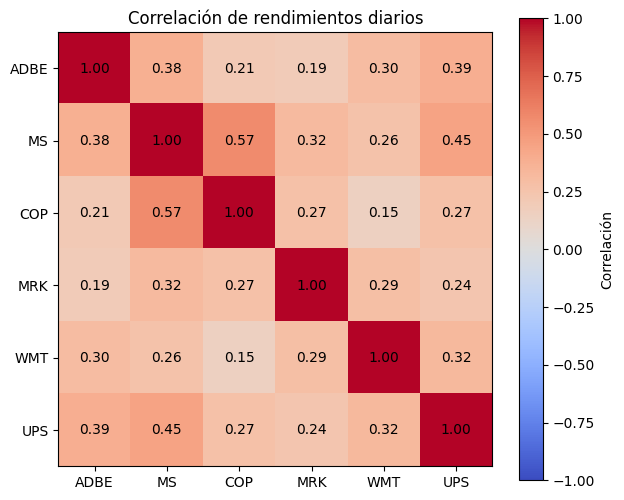

Par menos correlacionado: ('COP', 'WMT') 0.145
Par más correlacionado:   ('MS', 'COP') 0.567
Correlación promedio entre pares: 0.306


In [28]:
corr_mis = rend_mis.corr()
display(corr_mis.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_mis.values, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr_mis.columns)), labels=corr_mis.columns)
ax.set_yticks(range(len(corr_mis.index)), labels=corr_mis.index)
for i in range(len(corr_mis)):
    for j in range(len(corr_mis)):
        ax.text(j, i, f"{corr_mis.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Correlación")
ax.set_title("Correlación de rendimientos diarios")
plt.show()

# Pares de activos ordenados de menor a mayor correlación
pares = pd.Series({(a, b): corr_mis.loc[a, b] for a, b in combinations(corr_mis.columns, 2)}).sort_values()
print("Par menos correlacionado:", pares.index[0], round(pares.iloc[0], 3))
print("Par más correlacionado:  ", pares.index[-1], round(pares.iloc[-1], 3))
print("Correlación promedio entre pares:", round(pares.mean(), 3))

## 9.9 Interpretar — conclusión

La siguiente celda arma la conclusión con **los números que salieron de los datos**, así que el texto siempre coincide con las tablas y gráficas de arriba. Responde la pregunta final: *¿qué diferencias encontraste entre los activos y qué información consideras importante conocer antes de incorporarlos a un portafolio?*

In [29]:
vol_dia = resumen_rend["desv_std_%"]
p5 = resumen_rend["percentil_5_%"]

mejor, peor = variacion.idxmax(), variacion.idxmin()
mas_vol, menos_vol = vol_dia.idxmax(), vol_dia.idxmin()
p5_suave, p5_fuerte = p5.idxmax(), p5.idxmin()

if mejor == mas_vol:
    relacion = f"El activo de mayor variación acumulada ({mejor}) también fue el más volátil: más rendimiento vino acompañado de más riesgo."
else:
    relacion = f"El activo de mayor variación acumulada ({mejor}) no fue el más volátil ({mas_vol}): en este período el mayor rendimiento no coincidió con el mayor riesgo."

conclusion = f"""
### Conclusión ({inicio} a {fin})

- **Rendimiento:** {mejor} tuvo la mayor variación acumulada ({variacion[mejor]:+.1f} %) y {peor} la menor ({variacion[peor]:+.1f} %).
- **Riesgo:** {mas_vol} fue el más volátil (desviación estándar diaria de {vol_dia[mas_vol]:.2f} %) y {menos_vol} el menos volátil ({vol_dia[menos_vol]:.2f} %). {relacion}
- **Pérdidas extremas:** en el 5 % de los peores días, {p5_fuerte} perdió {abs(p5[p5_fuerte]):.2f} % o más, frente a {abs(p5[p5_suave]):.2f} % o más en {p5_suave}.
- **Relación entre activos:** el par más correlacionado fue {pares.index[-1][0]}–{pares.index[-1][1]} ({pares.iloc[-1]:.2f}) y el menos correlacionado {pares.index[0][0]}–{pares.index[0][1]} ({pares.iloc[0]:.2f}); la correlación promedio entre pares fue {pares.mean():.2f}. Una correlación alta aporta poca diversificación; una baja amortigua mejor las caídas.
- **Qué revisar antes de incorporarlos a un portafolio:** el rendimiento solo no basta. Hay que mirarlo junto con la volatilidad, los percentiles de pérdida y la correlación entre activos, confirmar que no haya valores faltantes y recordar que {inicio} a {fin} es una sola muestra del pasado, que no garantiza lo que ocurra después.
"""
display(Markdown(conclusion))


### Conclusión (2020-01-01 a 2025-01-01)

- **Rendimiento:** MS tuvo la mayor variación acumulada (+141.6 %) y UPS la menor (+8.0 %).
- **Riesgo:** COP fue el más volátil (desviación estándar diaria de 2.78 %) y WMT el menos volátil (1.42 %). El activo de mayor variación acumulada (MS) no fue el más volátil (COP): en este período el mayor rendimiento no coincidió con el mayor riesgo.
- **Pérdidas extremas:** en el 5 % de los peores días, COP perdió 3.73 % o más, frente a 1.89 % o más en WMT.
- **Relación entre activos:** el par más correlacionado fue MS–COP (0.57) y el menos correlacionado COP–WMT (0.15); la correlación promedio entre pares fue 0.31. Una correlación alta aporta poca diversificación; una baja amortigua mejor las caídas.
- **Qué revisar antes de incorporarlos a un portafolio:** el rendimiento solo no basta. Hay que mirarlo junto con la volatilidad, los percentiles de pérdida y la correlación entre activos, confirmar que no haya valores faltantes y recordar que 2020-01-01 a 2025-01-01 es una sola muestra del pasado, que no garantiza lo que ocurra después.


## 🎫 Salida de aprendizaje

Completa estas tres frases en una celda de texto:

- **Encontré que…**
- **La información que más me ayudó a comparar los activos fue…**
- **Antes de construir un portafolio, considero importante revisar…**


In [30]:
salida = f"""
- **Encontré que…** {mejor} tuvo la mayor variación acumulada ({variacion[mejor]:+.1f} %) y {mas_vol} fue el más volátil ({vol_dia[mas_vol]:.2f} % de desviación estándar diaria), y que el par más correlacionado fue {pares.index[-1][0]}–{pares.index[-1][1]} ({pares.iloc[-1]:.2f}).
- **La información que más me ayudó a comparar los activos fue…** la evolución normalizada en base 100 junto con la desviación estándar de los rendimientos, porque ponen activos con precios en escalas distintas en el mismo punto de partida y muestran cuánto riesgo hubo detrás de cada variación.
- **Antes de construir un portafolio, considero importante revisar…** la correlación entre los activos, la volatilidad y los percentiles de pérdida, los valores faltantes y el período de datos, porque el riesgo de un portafolio depende de cómo se mueven los activos juntos y de qué tan extremos pueden ser sus peores días.
"""
display(Markdown(salida))


- **Encontré que…** MS tuvo la mayor variación acumulada (+141.6 %) y COP fue el más volátil (2.78 % de desviación estándar diaria), y que el par más correlacionado fue MS–COP (0.57).
- **La información que más me ayudó a comparar los activos fue…** la evolución normalizada en base 100 junto con la desviación estándar de los rendimientos, porque ponen activos con precios en escalas distintas en el mismo punto de partida y muestran cuánto riesgo hubo detrás de cada variación.
- **Antes de construir un portafolio, considero importante revisar…** la correlación entre los activos, la volatilidad y los percentiles de pérdida, los valores faltantes y el período de datos, porque el riesgo de un portafolio depende de cómo se mueven los activos juntos y de qué tan extremos pueden ser sus peores días.
